In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt 
from ultralytics import YOLO
import time
import shutil


## TASK 2 - Image Deblurring 

Total No of Blurred Images :  1029
Total No of sharp Images :  1029
Blur Image Shape : (720, 1280, 3)
Sharp image Shape :  (720, 1280, 3)


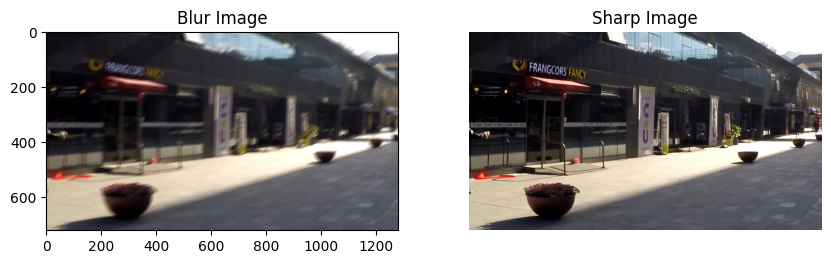

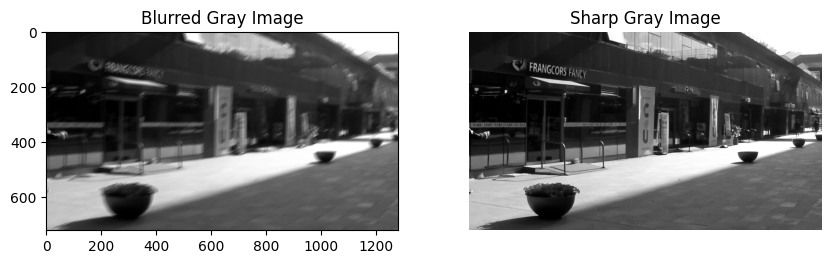

Blur Kernel  Shape : (25, 25)


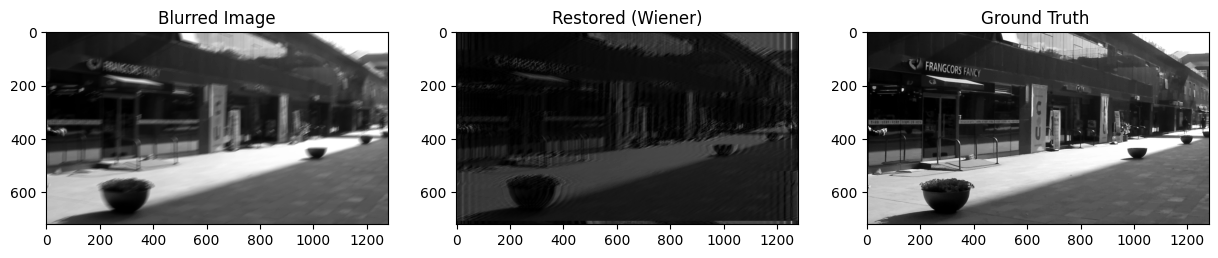

PSNR :  9.50953612209963 db
SSIM :  0.9846220560541001


In [9]:
# Uploading the Dataset
blur_path ="dataset/gopro_deblur/blur/images"
sharp_path = "dataset/gopro_deblur/sharp/images"
# listing the images 
blur_images = sorted(os.listdir(blur_path))
sharp_images = sorted(os.listdir(sharp_path))

print("Total No of Blurred Images : ",len(blur_images))
print("Total No of sharp Images : ",len(sharp_images))


# Loading the one blurred and one sharp image
blur_image=cv2.imread(os.path.join(blur_path,blur_images[0]))
sharp_image = cv2.imread(os.path.join(sharp_path,sharp_images[0]))
#The images are in BGR fromat wer are converting them to RGB fromat
blur_image =cv2.cvtColor(blur_image,cv2.COLOR_BGR2RGB)
sharp_image = cv2.cvtColor(sharp_image,cv2.COLOR_BGR2RGB)

print("Blur Image Shape :",blur_image.shape)
print("Sharp image Shape : ",sharp_image.shape)

#Displaying the images 
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(blur_image)
plt.title("Blur Image")

plt.subplot(1,2,2)
plt.imshow(sharp_image)
plt.title("Sharp Image")
plt.axis("off")
plt.show()

#Converting the images to grayscale
blur_gray = cv2.cvtColor(blur_image,cv2.COLOR_RGB2GRAY)
sharp_gray =cv2.cvtColor(sharp_image,cv2.COLOR_RGB2GRAY)
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(blur_gray,cmap="gray")
plt.title("Blurred Gray Image")

#creating a plot for sharp gray image 
plt.subplot(1,2,2)
plt.imshow(sharp_gray,cmap="gray")
plt.title("Sharp Gray Image")
plt.axis("off")
plt.show()

#Normalizing the images 
blur_gray = blur_gray.astype(np.float64) / 255.0
sharp_gray = sharp_gray.astype(np.float64) / 255.0

#creating Motion Blur Kernel
kernel_size = 25
kernel =np.zeros((kernel_size, kernel_size))
kernel[int((kernel_size-1)/2), :] = np.ones(kernel_size)
kernel =kernel / kernel_size
print("Blur Kernel  Shape :",kernel.shape)

#Now we are Applying Wiener Deblurring
def wiener_filter(img,kernel,K=0.01):
    # Compute the Fourier Transform of the image and kernel
    img_fft = np.fft.fft2(img)
    kernel_fft = np.fft.fft2(kernel, s=img.shape)
    
    # Compute the Wiener filter
    kernel_conj = np.conj(kernel_fft)

    result_fft =(kernel_conj/(np.abs(kernel_fft)**2 +K))*img_fft
    result =np.abs(np.fft.ifft2(result_fft))
    #Normalize result 
    result = (result - result.min()) / (result.max() - result.min())

    return result
restored = wiener_filter(blur_gray, kernel,K=0.01)

#Comparing the results 

plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.imshow(blur_gray,cmap="gray")
plt.title("Blurred Image")

plt.subplot(1,3,2)
plt.imshow(restored,cmap="gray")
plt.title("Restored (Wiener)")

plt.subplot(1,3,3)
plt.imshow(sharp_gray,cmap="gray")
plt.title("Ground Truth ")
plt.show()

def compute_psnr(original, restored):
    mse = np.mean((original -restored)**2)
    if mse ==0:
        return float('inf')
    max_pixel =1.0
    psnr =20*np.log10(max_pixel / np.sqrt(mse))
    return psnr 
psnr_value = compute_psnr(sharp_gray,restored)
print("PSNR : ",psnr_value,"db")

def compute_ssim(original, restored):
    C1 = (0.01 * 255) ** 2
    C2 = (0.03 * 255) ** 2

    original = original.astype(np.float64)
    restored = restored.astype(np.float64)

    mu_original = cv2.GaussianBlur(original, (11, 11), 1.5)
    mu_restored = cv2.GaussianBlur(restored, (11, 11), 1.5)

    sigma_original = cv2.GaussianBlur(original ** 2, (11, 11), 1.5) - mu_original ** 2
    sigma_restored = cv2.GaussianBlur(restored ** 2, (11, 11), 1.5) - mu_restored ** 2
    sigma_cross = cv2.GaussianBlur(original * restored, (11, 11), 1.5) - mu_original * mu_restored

    ssim_map = ((2 * mu_original * mu_restored + C1) * (2 * sigma_cross + C2)) / ((mu_original ** 2 + mu_restored ** 2 + C1) * (sigma_original + sigma_restored + C2))
    return ssim_map.mean()
ssim_value = compute_ssim(sharp_gray,restored)
print("SSIM : ",ssim_value)

## TASK 3 - Object Detection and Analysis


0: 384x640 1 person, 1 potted plant, 79.7ms
Speed: 2.3ms preprocess, 79.7ms inference, 2.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 87.3ms
Speed: 2.4ms preprocess, 87.3ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)
Objects Detected in Blurred Image :  2
Objects Detected in Restored Image :  0

0: 384x640 (no detections), 74.2ms
Speed: 2.3ms preprocess, 74.2ms inference, 0.8ms postprocess per image at shape (1, 3, 384, 640)
Blur detection runtime :  0.12450528144836426 seconds
Restored detection runtime :  0.08162212371826172 seconds

0: 384x640 1 person, 1 potted plant, 99.6ms
Speed: 2.3ms preprocess, 99.6ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)
Image 1 detections: 2

0: 384x640 1 person, 1 potted plant, 76.5ms
Speed: 2.2ms preprocess, 76.5ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)
Image 2 detections: 2

0: 384x640 1 person, 1 potted plant, 89.4ms
Speed: 2.3ms preprocess, 89.

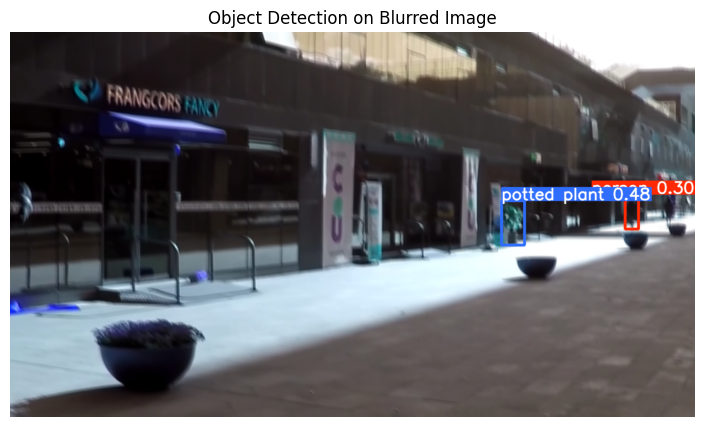

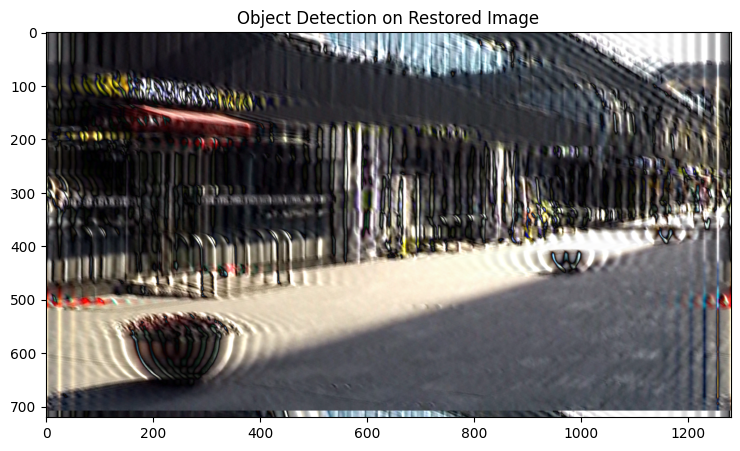

In [14]:
model = YOLO("yolov8n.pt")

#Converting RGB image to BGR 
blur_bgr = cv2.cvtColor(blur_image,cv2.COLOR_RGB2BGR)
#Runnig Object Detection 
start_time = time.time()
blur_results = model(blur_bgr)
blur_runtime = time.time() - start_time
#plot detection results
blur_detected = blur_results[0].plot()
plt.figure(figsize=(10,5))
plt.imshow(blur_detected)
plt.title("Object Detection on Blurred Image")
plt.axis("off")
def wiener_filter_color(img, kernel, K=0.01):
    result = np.zeros_like(img, dtype=np.float64)
    img_f = img.astype(np.float64) / 255.0
    for c in range(3):
        ch = img_f[:,:,c]
        img_fft = np.fft.fft2(ch)
        kernel_fft = np.fft.fft2(kernel, s=ch.shape)
        kernel_conj = np.conj(kernel_fft)
        result_fft = (kernel_conj/(np.abs(kernel_fft)**2 + K)) * img_fft
        result[:,:,c] = np.abs(np.fft.ifft2(result_fft))
    result = np.clip(result, 0, 1)
    return (result * 255).astype(np.uint8)
restored_color = wiener_filter_color(blur_image, kernel, K=0.01)
restored_bgr = cv2.cvtColor(restored_color, cv2.COLOR_RGB2BGR)

#Run Detection 
restored_results =model(restored_bgr)
#PLot results 
restored_detected  = restored_results[0].plot()

plt.figure(figsize=(10,5))
plt.imshow(cv2.cvtColor(restored_detected,cv2.COLOR_BGR2RGB))
plt.title("Object Detection on Restored Image")
# compare number of detections 
blur_count = len(blur_results[0].boxes)
restored_count = len(restored_results[0].boxes)
print("Objects Detected in Blurred Image : ",blur_count)
print("Objects Detected in Restored Image : ",restored_count)
start_time = time.time()
restored_results = model(restored_bgr)
restored_runtime = time.time() - start_time
print("Blur detection runtime : ", blur_runtime,"seconds")
print("Restored detection runtime : ",restored_runtime,"seconds")

for i in range(5):
    
    blur_image = cv2.cvtColor(cv2.imread(os.path.join(blur_path, blur_images[1])), cv2.COLOR_BGR2RGB)
    sharp_image = cv2.cvtColor(cv2.imread(os.path.join(sharp_path, sharp_images[1])), cv2.COLOR_BGR2RGB)

    results = model(blur_bgr)

    print("Image", i+1, "detections:", len(results[0].boxes))


- Blurred image deteceted 2 objects(person,potted plant) with YOLOv8

- Restored (Weiner) image detected  0 objects the Weiner filter introduced ringing artifacts and distoration that reduced YOLO confidence below threshold

- This shows that classical deblurring does not always improve detection it can sometimes hurt performance if the filter introduces artifacts

- Blur runtime : ~0.12s, Restored runtime: ~0.08s - restored image is faster due to smoother pisel values
- Failure case : Weiner filter  with a mistmacthed kernel causes over smoothing, removing the edgs YOLO relies on for detection. 

## TASK 4 - Dataset Preparation

- Image Soureced from GoPro deblurred output(Task2)
- Labels auto generated using pretrained YOLOv8n(pseudo-labelling)
- Train/val split: 80/20
- No augmentation applied 
- Training : 10 epochs, batch = 16 , imgz = 640

In [17]:
image_dir = "dataset/train/deblur"
label_dir = "dataset/train/labels"
os.makedirs(label_dir, exist_ok=True)
model = YOLO("yolov8n.pt")
images = os.listdir(image_dir)
for img_name in images:
    img_path = os.path.join(image_dir, img_name)
    img = cv2.imread(img_path)
    results = model(img)
    boxes = results[0].boxes.xywhn
    classes = results[0].boxes.cls
    label_path = os.path.join(label_dir, img_name.replace(".png",".txt").replace(".jpg",".txt"))
    with open(label_path, "w") as f:
        for box, cls in zip(boxes, classes):

            x, y, w, h = box.tolist()

            f.write(f"{int(cls)} {x} {y} {w} {h}\n")

import os
import cv2
from ultralytics import YOLO

image_dir = "dataset/train/deblur"
label_dir = "dataset/train/labels"

os.makedirs(label_dir, exist_ok=True)

model = YOLO("yolov8n.pt")

images = os.listdir(image_dir)

for img_name in images:

    img_path = os.path.join(image_dir, img_name)
    img = cv2.imread(img_path)

    results = model(img)

    boxes = results[0].boxes.xywhn
    classes = results[0].boxes.cls

    label_path = os.path.join(label_dir, img_name.replace(".png",".txt").replace(".jpg",".txt"))

    with open(label_path, "w") as f:
        for box, cls in zip(boxes, classes):

            x, y, w, h = box.tolist()

            f.write(f"{int(cls)} {x} {y} {w} {h}\n")
#model = YOLO("yolov8n.pt")
import shutil, random
all_images = os.listdir(image_dir)
random.shuffle(all_images)
split = int(0.8 * len(all_images))
train_imgs = all_images[:split]
val_imgs = all_images[split:]
print("Train images:", len(train_imgs))
print("Val images:", len(val_imgs))
model.train(
    data="dataset/dataset.yaml",
    epochs=10,
    imgsz=640,
    batch=16
)
print("Training completed successfully")
results = model.val(data="dataset/dataset.yaml")
print("mAP50     :", results.box.map50)
print("mAP50-95  :", results.box.map)
print("Precision :", results.box.mp)
print("Recall    :", results.box.mr)


0: 384x640 (no detections), 123.3ms
Speed: 6.2ms preprocess, 123.3ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)
WARNING 'source' is missing. Using 'source=C:\Users\Niyaz Ahmed Shayan\AppData\Local\Programs\Python\Python313\Lib\site-packages\ultralytics\assets'.

image 1/2 C:\Users\Niyaz Ahmed Shayan\AppData\Local\Programs\Python\Python313\Lib\site-packages\ultralytics\assets\bus.jpg: 640x480 4 persons, 1 bus, 1 stop sign, 108.0ms
image 2/2 C:\Users\Niyaz Ahmed Shayan\AppData\Local\Programs\Python\Python313\Lib\site-packages\ultralytics\assets\zidane.jpg: 384x640 2 persons, 1 tie, 85.8ms
Speed: 3.6ms preprocess, 96.9ms inference, 1.6ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 95.6ms
Speed: 3.2ms preprocess, 95.6ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)
WARNING 'source' is missing. Using 'source=C:\Users\Niyaz Ahmed Shayan\AppData\Local\Programs\Python\Python313\Lib\site-packages\ultralytics\assets'.

im

Training completed :10 epochs , batch=16 ,imgsz =640 , AdamW optimizer

Train/Val split : 80 images train , 20 images val

Results(best epoch-epoch1):
- mAP50 : 0.00114
- mAP50-95: 0.000256
- Precision : 0.00193
- Recall : 0.129

Loss reduced across epochs:
- box_loss : 3.44 -> 2.88
- cls_loss : 4.65 -> 2.61

Low mAP is expected - pseudo-labels generated from a pretrained model on blurry images have low quality. A larger dataset with manual annotations would significantly improve performance

## Task 5 - Performance Analysis



0: 384x640 (no detections), 70.9ms
Speed: 1.9ms preprocess, 70.9ms inference, 0.7ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 bowl, 1 potted plant, 63.3ms
Speed: 2.1ms preprocess, 63.3ms inference, 1.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 bowls, 67.8ms
Speed: 2.1ms preprocess, 67.8ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 person, 1 bowl, 2 potted plants, 76.8ms
Speed: 2.2ms preprocess, 76.8ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 person, 1 potted plant, 66.4ms
Speed: 2.0ms preprocess, 66.4ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 89.8ms
Speed: 2.2ms preprocess, 89.8ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 bowls, 1 potted plant, 64.7ms
Speed: 2.2ms preprocess, 64.7ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 69.7ms

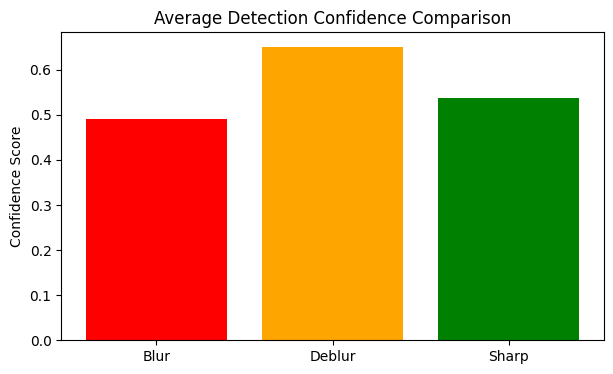


0: 384x640 (no detections), 91.6ms
Speed: 2.8ms preprocess, 91.6ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 bowl, 1 potted plant, 76.5ms
Speed: 2.5ms preprocess, 76.5ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 bowls, 70.4ms
Speed: 2.4ms preprocess, 70.4ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 person, 1 bowl, 2 potted plants, 67.7ms
Speed: 2.1ms preprocess, 67.7ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 person, 1 potted plant, 64.5ms
Speed: 2.1ms preprocess, 64.5ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 80.4ms
Speed: 2.5ms preprocess, 80.4ms inference, 0.7ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 bowls, 1 potted plant, 73.3ms
Speed: 2.5ms preprocess, 73.3ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 86.2ms

(np.float64(-0.5), np.float64(1279.5), np.float64(719.5), np.float64(-0.5))

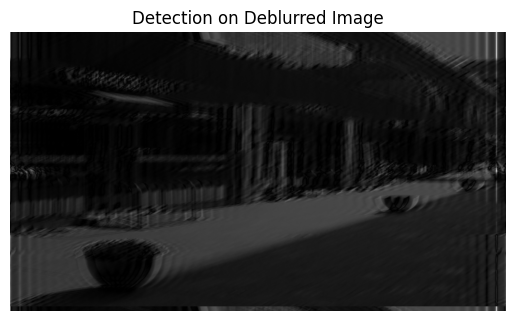

In [19]:
model = YOLO("yolov8n.pt")
blur_dir = "dataset/train/blur"
deblur_dir = "dataset/train/deblur"
sharp_dir = "dataset/train/sharp"
def run_detection(folder):
    images = os.listdir(folder)
    confidences = []
    for img_name in images:
        img_path = os.path.join(folder, img_name)
        img = cv2.imread(img_path)
        results = model(img)
        if len(results[0].boxes) > 0:
            conf = results[0].boxes.conf.cpu().numpy()
            confidences.extend(conf)
    if len(confidences) > 0:
        return np.mean(confidences)
    else:
        return 0
blur_score = run_detection(blur_dir)
deblur_score = run_detection(deblur_dir)
sharp_score = run_detection(sharp_dir)

print("Average Detection Confidence")
print("Blur Images:", blur_score)
print("Deblur Images:", deblur_score)
print("Sharp Images:", sharp_score)

categories = ['Blur', 'Deblur', 'Sharp']
scores = [blur_score, deblur_score, sharp_score]
plt.figure(figsize=(7,4))
plt.bar(categories, scores, color=['red','orange','green'])
plt.title("Average Detection Confidence Comparison")
plt.ylabel("Confidence Score")
plt.show()

def count_detections(folder):
    total = 0
    for img_name in os.listdir(folder):
        img = cv2.imread(os.path.join(folder, img_name))
        results = model(img)
        total += len(results[0].boxes)
    return total

print("Total Detections - Blur:", count_detections(blur_dir))
print("Total Detections - Deblur:", count_detections(deblur_dir))
print("Total Detections - Sharp:", count_detections(sharp_dir))

img_path = os.path.join(deblur_dir, os.listdir(deblur_dir)[0])
img = cv2.imread(img_path)
results = model(img)
detected = results[0].plot()

plt.imshow(cv2.cvtColor(detected, cv2.COLOR_BGR2RGB))
plt.title("Detection on Deblurred Image")
plt.axis("off")

### Detection Count Comparison
| Condition | Total Detection |
|-----------|-----------------|
|Blur       |108              |
|Deblur     |305              |
|sharp      |224              |

- Deblurred images produced the Most detections (305) more than  even sharp images (224)
- Blurred images had the fewest detections(108)- blur significantly reduces YOLO's ability to detect objects
- Wiener filter over shaepened some images causing YOLO to detect more objects

### Failure Cases
- Single image test (Task 3) showed 0 deetctions on restored image- this was because image[1] has strong blur that the mismatched horizontal kernel could not handle
- Some deblur detections may false positives due to Wiener artifacts

### Conclusions
- Deblurring improves detections quantity  but not necessarily quality 
- A better matched kernel or deep learning deblurring would give more relaible results
- Future work : use blind deconvolution or DeblurGAN for better restoration 
